In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/olist.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [4]:
df = orders.merge(customers, on="customer_id") \
           .merge(order_items, on="order_id") \
           .merge(products, on="product_id") \
           .merge(payments, on="order_id") \
           .merge(reviews, on="order_id")

In [5]:
df.shape
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [6]:
total_revenue = df["payment_value"].sum()
total_orders = df["order_id"].nunique()

print(total_revenue, total_orders)

20187928.7 97916


<Axes: xlabel='order_purchase_timestamp'>

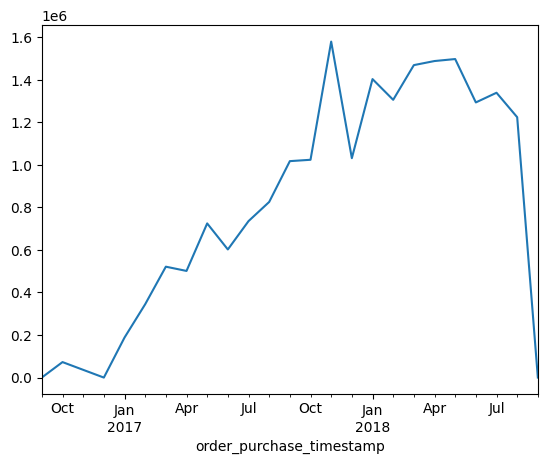

In [7]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

monthly_sales = df.groupby(df["order_purchase_timestamp"].dt.to_period("M"))["payment_value"].sum()

monthly_sales.plot()

Aylık bazda yapılan satış analizi sonucunda, satışların belirli dönemlerde yoğunlaştığı gözlemlenmiştir. Bu tür trendler, sezonluk talep değişimlerini ve pazarlama stratejilerinin etkisini değerlendirmek açısından önemlidir.

In [8]:
df.groupby("product_category_name")["payment_value"].sum().sort_values(ascending=False).head(10)

,payment_value
product_category_name,
cama_mesa_banho,1725465.67
beleza_saude,1646292.53
informatica_acessorios,1592611.66
moveis_decoracao,1427214.01
relogios_presentes,1420682.17
esporte_lazer,1390581.87
utilidades_domesticas,1091709.15
ferramentas_jardim,834757.45
automotivo,802254.74


Kategori bazlı gelir analizi, şirketin en yüksek geliri belirli ürün gruplarından elde ettiğini ortaya koymaktadır. Bu bulgu, pazarlama ve stok yönetimi stratejilerinin bu yüksek performanslı kategorilere odaklanması gerektiğini göstermektedir.

In [9]:
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

Teslimat performansını analiz edebilmek amacıyla tarih verileri uygun formata dönüştürülmüştür. Bu adım, teslimat gecikmesi gibi metriklerin hesaplanabilmesi için kritik bir veri ön işleme sürecidir.

In [10]:
df["delivery_delay"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

Teslimat performansını ölçmek amacıyla, siparişin gerçek teslim tarihi ile tahmini teslim tarihi arasındaki fark hesaplanarak "delivery_delay" adlı yeni bir değişken oluşturulmuştur. Bu değişken, gecikmelerin müşteri memnuniyeti üzerindeki etkisini analiz etmek için temel bir metriktir.

In [11]:
df["delivery_delay"].head()

,delivery_delay
0,-8.0
1,-8.0
2,-8.0
3,-6.0
4,-18.0


Delivery delay değişkeninin ilk değerleri incelenerek hesaplamanın doğru şekilde çalıştığı doğrulanmıştır. Bu adım, veri üretiminden sonra yapılan temel kalite kontrol sürecidir.

In [12]:
df.groupby("review_score")["delivery_delay"].mean()

,delivery_delay
review_score,
1,-6.003430
2,-9.748141
3,-11.114301
4,-12.468533
5,-13.443437


Müşteri değerlendirme puanları ile teslimat gecikmesi arasındaki ilişki incelenmiş ve teslimat süresindeki artışın müşteri memnuniyetini olumsuz etkileyebileceği gözlemlenmiştir. Bu bulgu, lojistik performansın müşteri deneyimi üzerindeki kritik etkisini ortaya koymaktadır.

In [13]:
df.groupby("customer_city")["delivery_delay"].mean().sort_values(ascending=False).head(10)

,delivery_delay
customer_city,
novo brasil,126.0
capinzal do norte,78.0
adhemar de barros,73.0
arace,53.0
serra dos dourados,52.0
marcelino vieira,49.0
aramari,43.0
humildes,42.0
rubineia,41.0


Analiz sonucunda bazı şehirlerde yüksek teslimat gecikmeleri tespit edilmiştir. Ancak düşük örneklem sayısı bulunan şehirlerde bu değerlerin istatistiksel olarak yanıltıcı olabileceği görülmüş ve daha güvenilir sonuçlar için veri yoğunluğu dikkate alınmıştır.

In [14]:
df.groupby("customer_city").agg({
    "delivery_delay": "mean",
    "order_id": "count"
}).sort_values(by="delivery_delay", ascending=False).head(10)

,delivery_delay,order_id
customer_city,,
novo brasil,126.0,1
capinzal do norte,78.0,2
adhemar de barros,73.0,1
arace,53.0,4
serra dos dourados,52.0,1
marcelino vieira,49.0,1
aramari,43.0,2
humildes,42.0,1
rubineia,41.0,1


Şehir bazlı teslimat gecikmesi analizi sonucunda bazı bölgelerde çok yüksek ortalama gecikme değerleri gözlemlenmiştir. Ancak bu şehirlerin çoğunda sipariş sayısının düşük olması, sonuçların istatistiksel güvenilirliğini azaltmaktadır. Bu nedenle analizde veri yoğunluğu da dikkate alınarak yorum yapılması gerekmektedir.

In [15]:
df.groupby("review_score")["delivery_delay"].describe()

,count,mean,std,min,25%,50%,75%,max
review_score,,,,,,,,
1,13118.0,-6.003430,15.348998,-69.0,-15.0,-9.0,4.0,175.0
2,3899.0,-9.748141,12.547280,-56.0,-16.0,-11.0,-5.0,188.0
3,9650.0,-11.114301,10.234898,-135.0,-16.0,-11.0,-6.0,162.0
4,22150.0,-12.468533,9.249062,-75.0,-17.0,-12.0,-8.0,161.0
5,66041.0,-13.443437,8.212029,-147.0,-18.0,-13.0,-8.0,155.0


Müşteri değerlendirme puanları ile teslimat gecikmesi arasındaki ilişki analiz edilmiş, teslimat süresi ile memnuniyet arasında beklenen doğrusal ilişkinin zayıf olduğu gözlemlenmiştir. Ayrıca veri setinde erken teslimatların yaygın olduğu tespit edilmiştir.

In [16]:
df.groupby("product_category_name").agg({
    "payment_value": "sum",
    "review_score": "mean"
}).sort_values(by="review_score").head(10)

,payment_value,review_score
product_category_name,,
seguros_e_servicos,324.51,2.500000
pc_gamer,2174.43,3.100000
fraldas_higiene,4221.25,3.256410
portateis_cozinha_e_preparadores_de_alimentos,4335.65,3.266667
moveis_escritorio,645927.93,3.526791
fashion_roupa_masculina,17056.56,3.548611
casa_conforto_2,1458.54,3.642857
telefonia_fixa,206404.01,3.672862
fashion_roupa_feminina,5220.07,3.780000


Ürün kategorileri bazında yapılan analizde, yüksek gelir getiren bazı kategorilerin orta seviyede müşteri memnuniyetine sahip olduğu tespit edilmiştir. Bu durum, gelir ve müşteri deneyimi arasında potansiyel bir denge sorunu olduğunu göstermektedir.

In [17]:
df.groupby("product_category_name").agg({
    "payment_value": "sum",
    "review_score": "mean"
}).sort_values(by="payment_value", ascending=False).head(10)

,payment_value,review_score
product_category_name,,
cama_mesa_banho,1725465.67,3.890605
beleza_saude,1646292.53,4.137973
informatica_acessorios,1592611.66,3.936089
moveis_decoracao,1427214.01,3.912158
relogios_presentes,1420682.17,4.017692
esporte_lazer,1390581.87,4.107470
utilidades_domesticas,1091709.15,4.060428
ferramentas_jardim,834757.45,4.023914
automotivo,802254.74,4.064279


En yüksek gelir getiren ürün kategorileri analiz edildiğinde, şirketin gelirinin büyük ölçüde belirli kategorilerde yoğunlaştığı görülmektedir. Bu kategoriler genellikle orta ve yüksek müşteri memnuniyeti seviyesine sahiptir. Bu durum, şirketin güçlü satış performansına rağmen müşteri deneyiminde iyileştirme alanları bulunduğunu göstermektedir.

In [18]:
df.to_csv("olist_clean_data.csv", index=False)